## Intro

__Summary of the experiment__: BW25113 + pAR305 (Cra sensor) in M9+0.5% Mannose at 37 C. In the same experiment, there is the ∆ptsG + pAR305 in Mannose and both strains in 0.5% glucose.  __Repeat #1.__


_Imaging conditions:_ YFP channel ?%, xx ms exposure, xx gain; same? for the CFP channel. Fluorescent channel pictures were aligned to brightfield manually.


__What this script does__: quantification of cell size (area and length, either given by MicrobeJ, or by analyzing the binary masks) and saves the resulting dataframe in a `.pkl` file.

__elab entry:__ https://elabjournal.rug.nl/members/experiments/browser/#view=experiment&nodeID=411900&page=0&userID=0&status=0&column=created&order=DESC&search=



__Starting date of the analysis:__ 2025.05.22

In [167]:
from datetime import datetime

time = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
print("Notebook started running on: ", time)

Notebook started running on:  31/07/2025 10:20:14


In [168]:
## Define inputs
path_base = r'/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250729_MKO305/'
path_imgs = path_base + r"tifffiles/"
path_mj = path_base + r"microbej/"

path_out = path_base + r"Analysis/"

folders = ["01_masks", "02_preprocessing", "03_plots"]

#### 0.1. Import packages

In [169]:
import glob
import os
import time
import pims 
import pandas as pd
import numpy as np
import trackpy as tp
import seaborn as sns
import _pickle as pickle
import skimage.io
import skimage.morphology
import scipy.io as sio
from scipy import ndimage, stats
from matplotlib import animation
import matplotlib.pyplot as plt
from pathlib import Path

In [170]:
import mahotas

In [171]:
import sys
sys.path.append(fr"{path_base}scripts/imgan")
import image_v3 as im  
import particle as prtc 
import results as rstl  
import auxiliary as aux
# import git

# repo = git.Repo(path="W:\Scripts\image-analysis")
# sha = repo.head.object.hexsha
# print("Using image-analysis scripts from commit: {}".format(sha))

In [172]:
## Module versions:
from importlib.metadata import version

modules = ["pandas", "seaborn", "matplotlib", "numpy", "scipy", "scikit-image", "pims", "trackpy"]

for m in modules:
    print("{}: ".format(m)+ version(m))

pandas: 2.2.3
seaborn: 0.13.2
matplotlib: 3.10.3
numpy: 2.2.5
scipy: 1.15.3
scikit-image: 0.25.2
pims: 0.7
trackpy: 0.6.4


#### 0.2. Define plotting settings

In [173]:
rc={"xtick.top": True, "xtick.bottom": True, "ytick.left": True, "ytick.right": True,
    "axes.spines.top": True, "axes.spines.right": True, 
    "xtick.direction": "in", "ytick.direction": "in", 
    "figure.frameon": True, "axes.grid":True,
    "grid.linestyle": ":", "grid.alpha": "0.3"}

sns.set(context="notebook", 
            style="white", palette="tab10", 
            font="sans-serif", font_scale=1.4, color_codes=False, rc=rc)

#### 0.3. Create output folders

In [174]:
for ff in folders:
    dirPath = path_out+ff
    if not os.path.isdir(dirPath):
        print('The directory is not present. Creating a new one..')
        os.mkdir(dirPath)
    else:
        print('The directory is present.')

The directory is present.
The directory is present.
The directory is present.


## 1. Import and store data

In [175]:
def store_results(img, df_out, name):
    
    df_img = img.results     # retrieve the results table of each image
    if df_out.empty:
        df_out = df_img.copy()
    else:
        df_out = pd.concat([df_out, df_img], join="inner", ignore_index=True)

    df_out["Type"] = name 
    
    return df_out

#### 1.1. Import .tifs

In [176]:
all_tif = glob.glob(os.path.join(path_imgs, "*.tiff"))

In [177]:
all_tif = [x for x in all_tif ] # if ("_bf" in x)]  # only BF .tif files

In [178]:
images = {}
for path in all_tif:
    fname = aux.get_basename(path)
    images[fname] = skimage.io.imread(path)

In [179]:
images.keys()

dict_keys(['20250729_MKO305_01', '20250729_MKO305_02', '20250729_MKO305_03', '20250729_MKO305_04'])

#### 1.2. Import microbeJ results

In [180]:
all_mj = glob.glob(os.path.join(path_mj, "*.mat"))

In [181]:
mj = {}
for path in all_mj:
    fname = aux.get_basename(path)
    print(fname)
    df_mj = sio.loadmat(path, simplify_cells=True)
    mj[fname] = df_mj["Experiment"]

MKO305_02
MKO305_03
MKO305_01
MKO305_04


#### 1.3. Establish correspondence with MicrobeJ results

In [182]:
#changed the code to establish correspondence to my file naming system. 
#Difference is that it looks for the complete path names instead of only the stems
correspondence = {}

for mat_file in all_mj:
    mat_base = Path(mat_file).stem.lower()  # e.g. "mwt305_01"

    for tifname in images.keys():
        tif_base = Path(tifname).stem.lower()  # e.g. "20250514_mwt305_01"

        if mat_base in tif_base:
            correspondence[tifname] = mat_file

correspondence

{'20250729_MKO305_02': '/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250729_MKO305/microbej/MKO305_02.mat',
 '20250729_MKO305_03': '/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250729_MKO305/microbej/MKO305_03.mat',
 '20250729_MKO305_01': '/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250729_MKO305/microbej/MKO305_01.mat',
 '20250729_MKO305_04': '/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/20250729_MKO305/microbej/MKO305_04.mat'}

In [183]:
# all_mj = [x for x in all_mj]   

# correspondence = {}

# for i, fname in enumerate(all_mj):
#     fname = aux.get_basename(fname)
#     try:
#         strain, cond, sample = fname.split("_", 2) #csource, 
        
#         strain = strain.lower()
#         cond = cond.lower()
# #         csource = csource.lower()
#         sample = sample.lower()
        
#         for tifname in images.keys():
#             tifnamel = tifname.lower()
#             if  (cond in tifnamel) and ("_"+sample in tifnamel):  # (strain in tifnamel) and (csource in tifnamel) and 

#                 correspondence[tifname] = fname
                
#     except:
#         strain, cond, sample = fname.split("_", 2)
#         strain = strain.lower()
#         cond = cond.lower()
#         sample = sample.lower()
        
#         for tifname in images.keys():
#             tifnamel = tifname.lower()
            
#             if (strain in tifnamel) and (cond+"_" in tifnamel) and ("_"+sample in tifnamel):
#                 correspondence[tifname] = fname   
                
            
# correspondence

#### 1.4. Store info in Image()

In [184]:
for img in images:
    print(img, images[img].shape)

20250729_MKO305_01 (1800, 1800, 3)
20250729_MKO305_02 (1800, 1800, 3)
20250729_MKO305_03 (1800, 1800, 3)
20250729_MKO305_04 (1800, 1800, 3)


In [185]:
to_ignore = [""]

In [186]:
imglist = []

for tif, mat in correspondence.items():
    if tif not in to_ignore:
        img_i = im.Image()
                
        infodict = {"um_pixel": 0.064,
                    "channels": {"bf": 0,
                                 "cfp": 1,
                                 "yfp": 2}}

        img_i.stack_raw = (images[tif], "xyc")  #  workaround to import a single frame (2021.01.26)
        
        
        infodict["name"] = tif
        print(tif)
        img_i.info = infodict
        img_i.microbej = mj[Path(mat).stem] # changed line here to only use the stem instead of whole path
        img_i.inspect_data()
        imglist.append(img_i)

20250729_MKO305_02
.. Stack provided has 3 channel(s) and 1 timepoint(s).
20250729_MKO305_03
.. Stack provided has 3 channel(s) and 1 timepoint(s).
20250729_MKO305_01
.. Stack provided has 3 channel(s) and 1 timepoint(s).
20250729_MKO305_04
.. Stack provided has 3 channel(s) and 1 timepoint(s).


In [187]:
for img_i in imglist:
    print(img_i.info)
    print("")

{'name': '20250729_MKO305_02', 'channels': {'bf': 0, 'cfp': 1, 'yfp': 2}, 'um_pixel': 0.064, 'shape': (1800, 1800), 'no_channels': 3, 'no_timepoints': 1, 'fps': []}

{'name': '20250729_MKO305_03', 'channels': {'bf': 0, 'cfp': 1, 'yfp': 2}, 'um_pixel': 0.064, 'shape': (1800, 1800), 'no_channels': 3, 'no_timepoints': 1, 'fps': []}

{'name': '20250729_MKO305_01', 'channels': {'bf': 0, 'cfp': 1, 'yfp': 2}, 'um_pixel': 0.064, 'shape': (1800, 1800), 'no_channels': 3, 'no_timepoints': 1, 'fps': []}

{'name': '20250729_MKO305_04', 'channels': {'bf': 0, 'cfp': 1, 'yfp': 2}, 'um_pixel': 0.064, 'shape': (1800, 1800), 'no_channels': 3, 'no_timepoints': 1, 'fps': []}



## 2. Generate contours

In [188]:
for img_i in imglist:
    print(img_i.info["name"])
    img_i.generate_mask(shift_pixel=-0.5)
    img_i.inspect_mask()

20250729_MKO305_02
Labels go from 1 to 52
20250729_MKO305_03
Labels go from 1 to 65
20250729_MKO305_01
Labels go from 1 to 54
20250729_MKO305_04
Labels go from 1 to 47


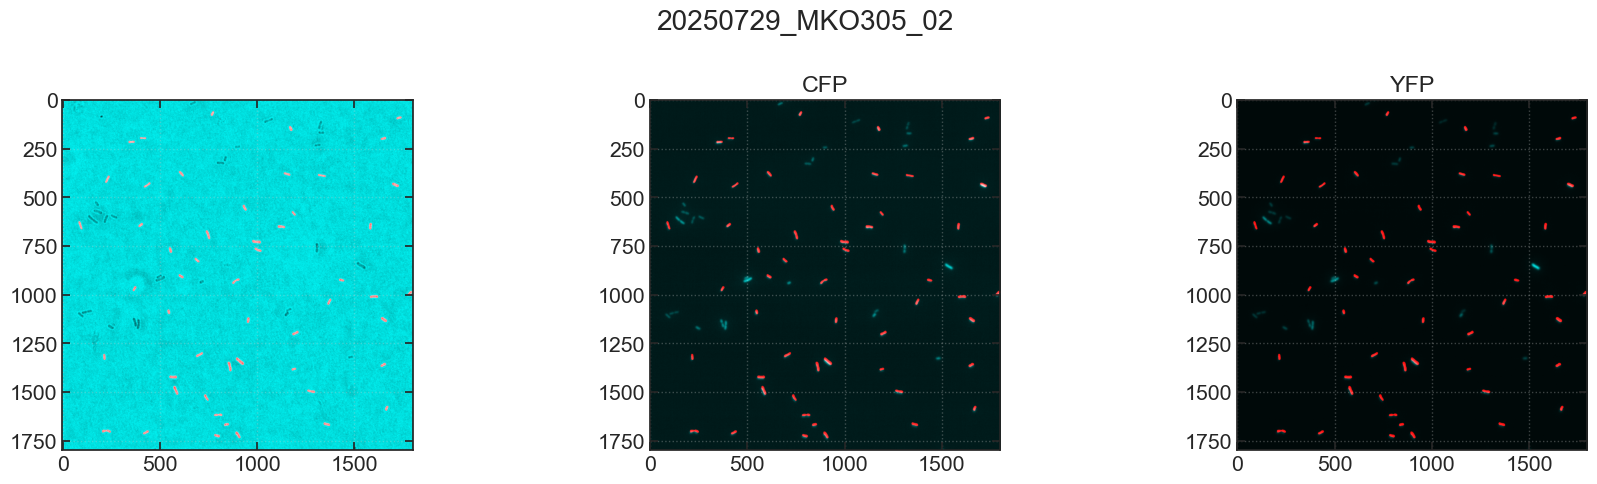

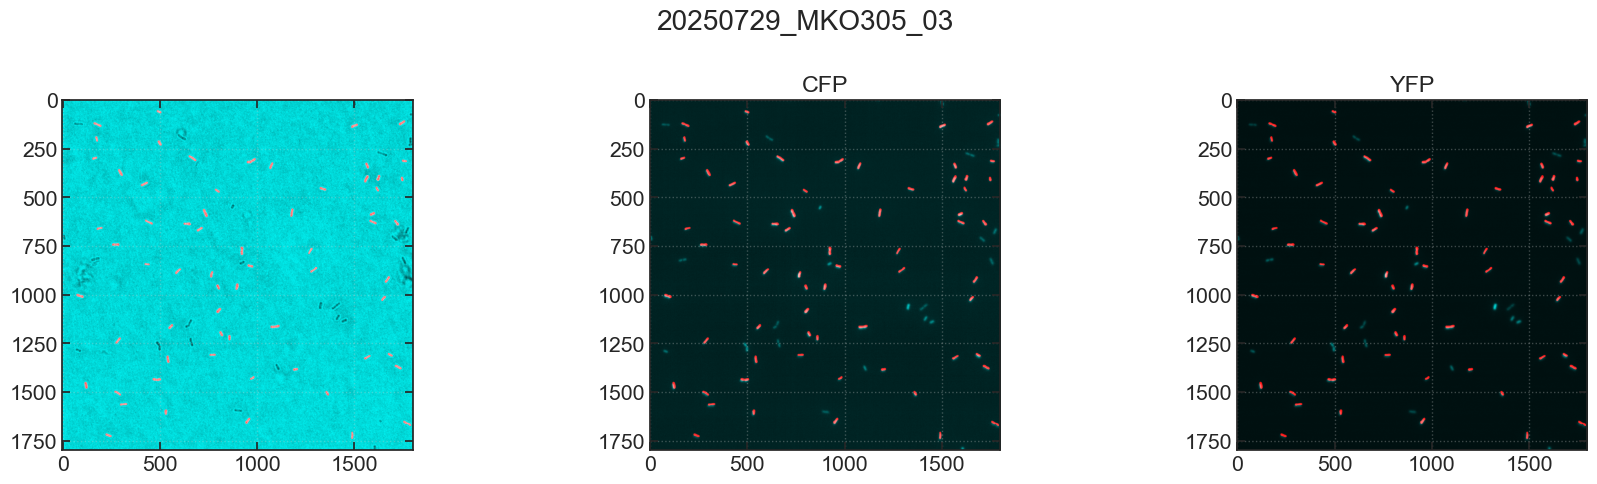

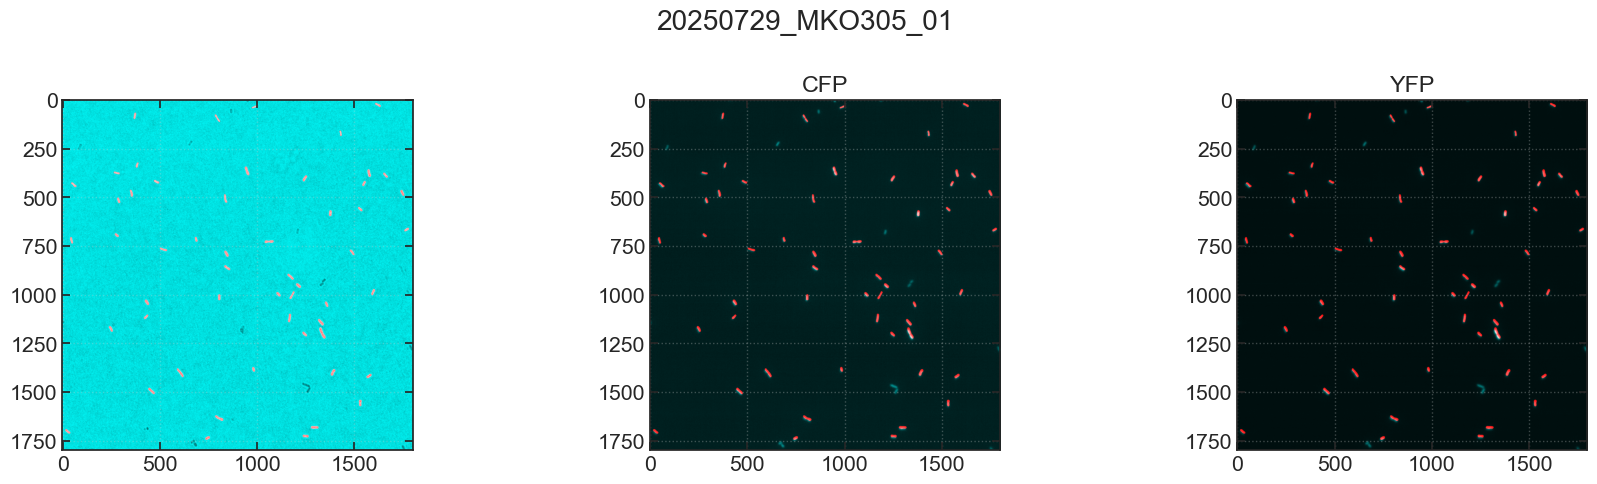

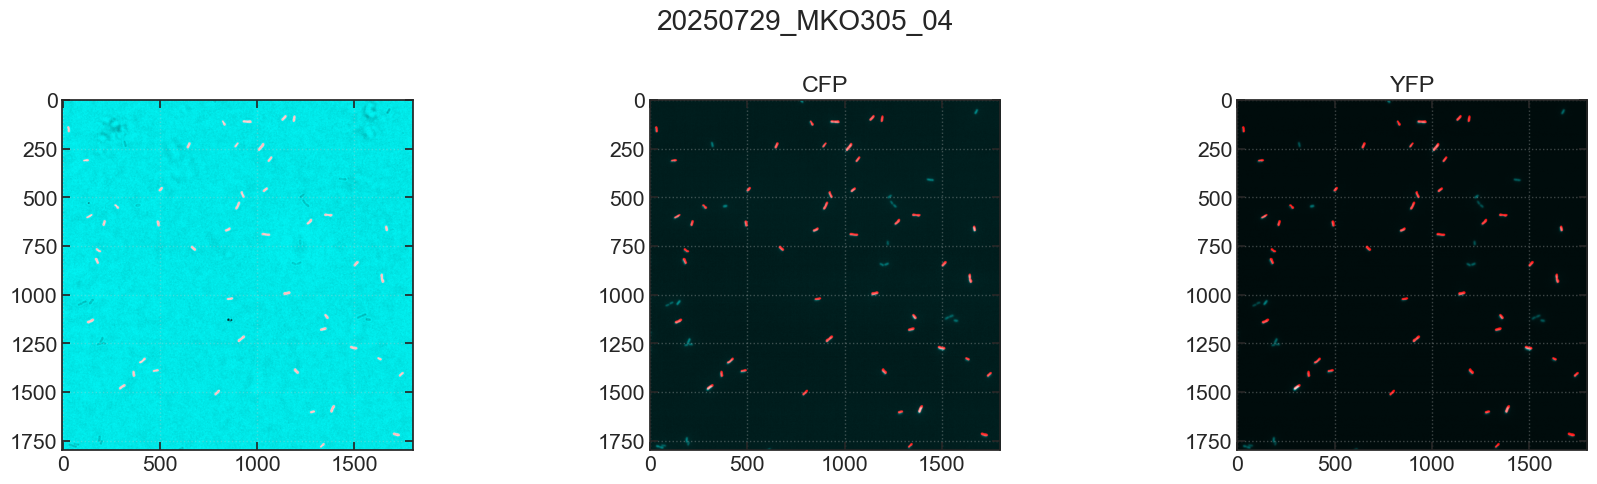

In [189]:
for img_i in imglist:
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    plt.suptitle(img_i.info["name"])
    img_i.display_stack("raw", "bf", t=0, overlay=True, ax= ax[0])
    
    img_i.display_stack("raw", "cfp", t=0, overlay=True, ax=ax[1])
    ax[1].set_title("CFP")

    img_i.display_stack("raw", "yfp", t=0, overlay=True, ax=ax[2])
    ax[2].set_title("YFP")
    plt.tight_layout()
#    plt.savefig("{}01_masks/{}_maskoverlay.png".format(path_out, img_i.info["name"]))
    plt.show()

3. Image registration 

In [190]:
# Image registration not done because pictures were aligned manually with the microscope software


# for img_ii in imglist:
#     if img_i.info["name"] in img_j.info["name"]:
#         ref = img_i.stack_raw[3,0,:,:].copy()
#         mov = img_j.stack_raw[0,0,:,:].copy()
#         img_mov_s = img_j.stack_raw[0, :, :, :].copy()
#         sr = img_i._get_transformation("rigid")  #
        
#         img_ref_norm = aux.normalize_intensity(ref) # 
#         img_mov_norm = aux.normalize_intensity(mov) # 
#         tmatrix = img_i._calc_matrix(img_ref_norm, img_mov_norm, tmatrix=None, sr=sr) 
    
    
#         print(tmatrix.shape, img_mov_s.shape)
#         tmatrix = img_i._match_matrixdim(tmatrix, img_mov_s)
#         out_rot = sr.transform_stack(img_mov_s, tmats=tmatrix)            
#         f, ax = plt.subplots(1,5, figsize=(20,5))
#         ax[0].imshow(ref)
#         ax[1].imshow(mov)
#         ax[2].imshow(out_rot[0,:,:])
#         ax[3].imshow(out_rot[40,:,:])
#         ax[4].imshow(aux.normalize_intensity(out_rot[40,:,:])-aux.normalize_intensity(ref))
#         plt.show()

## 3. Filter images

In [191]:
for img_i in imglist:
    img_i.apply_bandpassfilter("raw", "cfp", 1, 131)
    img_i.apply_bandpassfilter("bandpass", "yfp", 1, 131)

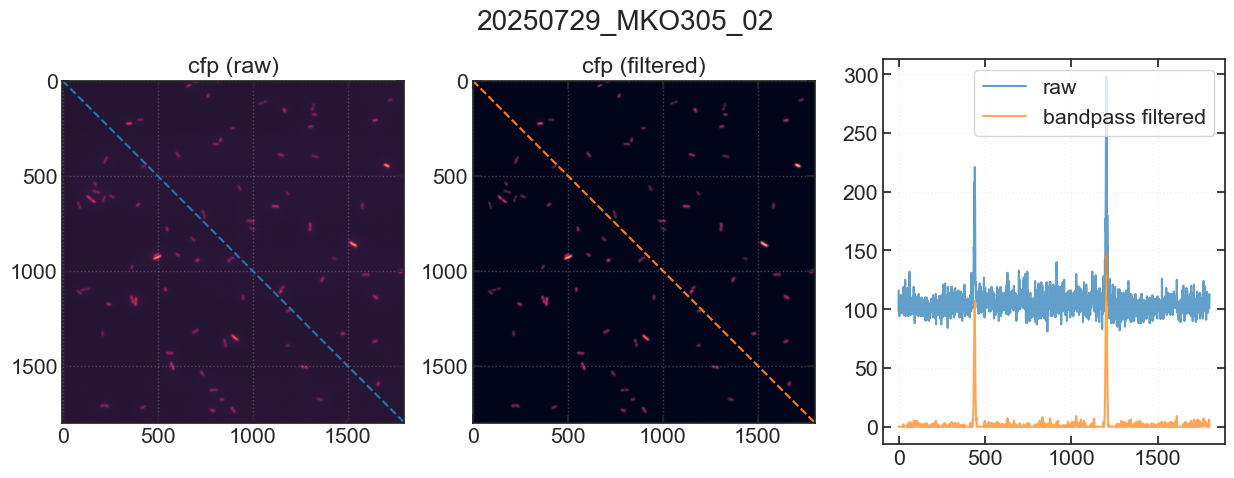

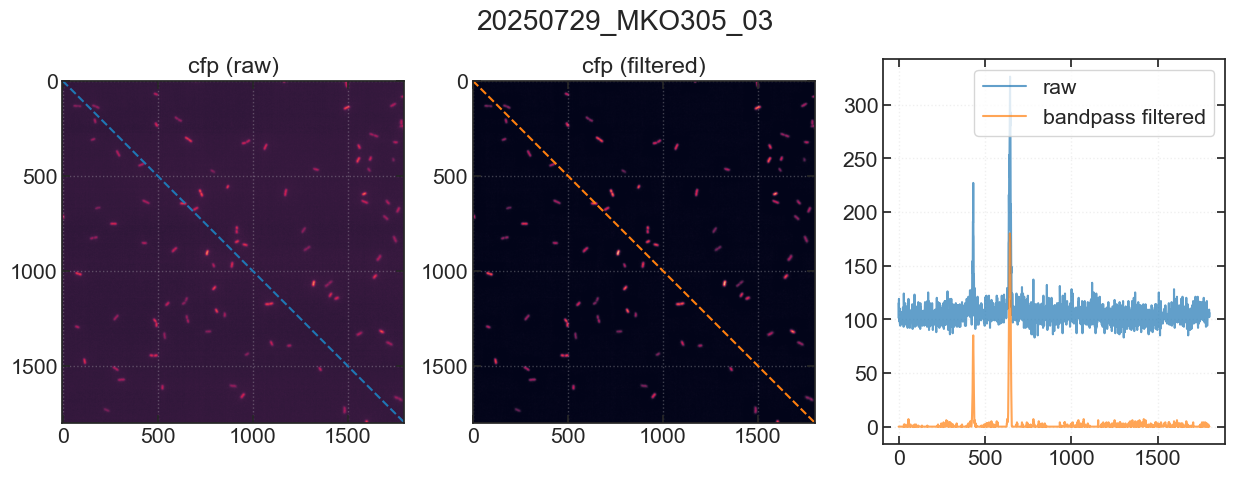

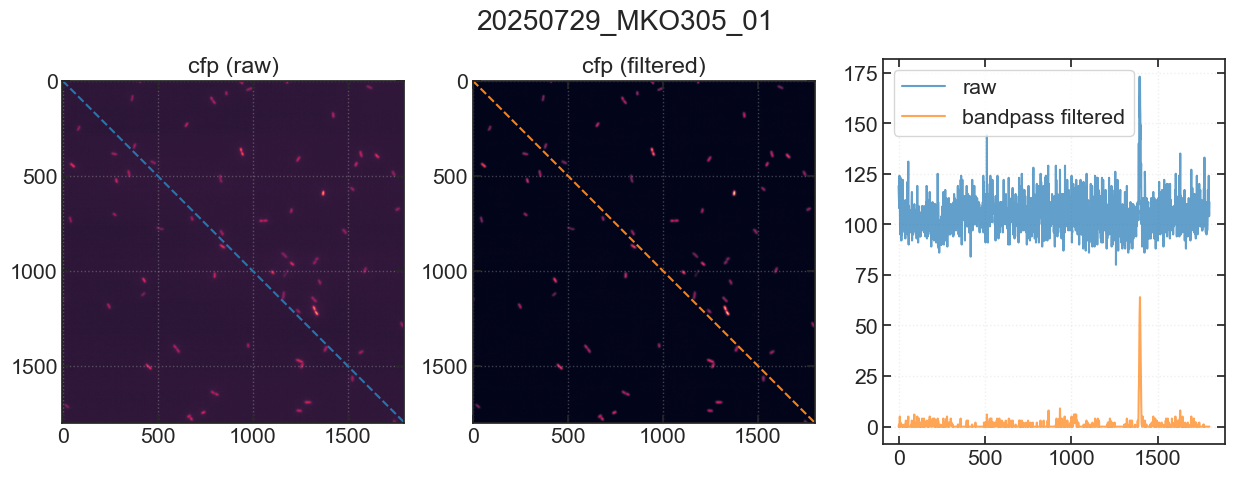

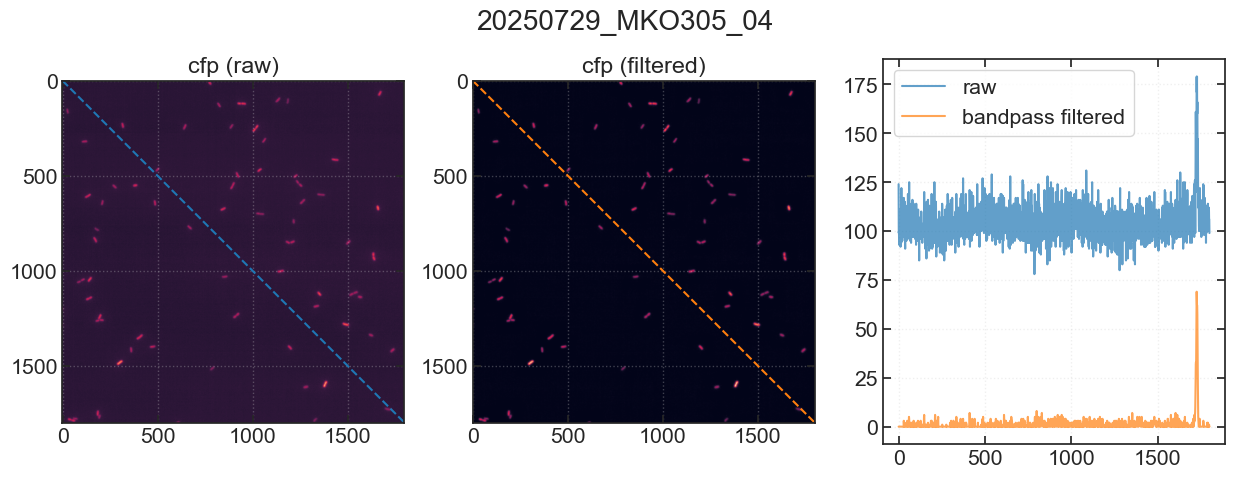

In [192]:
channel = "cfp"

for img_i in imglist:
    f, ax = plt.subplots(1,3, figsize=(15,5))
    
    idx, ch = img_i._get_channel(channel)
    
    img_raw = img_i.stack_raw[idx, 0, :,:]
    img_bp = img_i.stack_bandpass[idx, 0, :,:]
    ax[0].imshow(img_raw)
    ax[0].plot([0, 1], [1, 0], transform=ax[0].transAxes, linestyle="--")
    ax[0].set_title(ch + " (raw)")
    ax[1].imshow(img_bp)
    ax[1].plot([0, 1], [1, 0], transform=ax[1].transAxes, linestyle="")
    ax[1].plot([0, 1], [1, 0], transform=ax[1].transAxes, linestyle="--")
    ax[1].set_title(ch + " (filtered)")
    ax[2].plot(img_raw.diagonal(), label="raw", alpha=0.7)
    ax[2].plot(img_bp.diagonal(), label="bandpass filtered", alpha=0.7)
#     ax[2].set_title("Intensity along diagonal")
    ax[2].legend()
    
    plt.suptitle(img_i.info["name"])
#   plt.savefig("{}/02_preprocessing/{}_approach2_apply-bandpass-on-rawstack.png".format(path_out, img_i.info["name"]))
    plt.show()

## 4. Cell size distribution

#### 4.1. Quantify area of each mask (using `skimage`)

In [193]:
####################
data_to_store = "bandpass"
####################


props = ["label", "area", "mean_intensity", "max_intensity"]

for img_i in imglist:
    img_i.quantify_fluorescence(data_to_store, props, t=0)

In [194]:
df_total = pd.DataFrame({})
for img_i in imglist:
    df_total = store_results(img_i, df_total, data_to_store)
df_total

,cell no.,area,mean_bf,max_bf,image,t,max_cfp,mean_cfp,max_yfp,mean_yfp,Type
0,1,468.0,65244.929487,65535.0,20250729_MKO305_02,0,112.0,32.517094,167.0,50.831197,bandpass
1,2,535.0,65231.968224,65535.0,20250729_MKO305_02,0,158.0,53.848598,247.0,99.833645,bandpass
2,3,345.0,65222.159420,65482.0,20250729_MKO305_02,0,120.0,47.681159,213.0,93.162319,bandpass
3,4,441.0,65259.038549,65493.0,20250729_MKO305_02,0,144.0,79.489796,207.0,121.029478,bandpass
4,5,345.0,65262.617391,65522.0,20250729_MKO305_02,0,246.0,133.794203,503.0,260.791304,bandpass
...,...,...,...,...,...,...,...,...,...,...,...
213,43,254.0,65328.559055,65535.0,20250729_MKO305_04,0,123.0,54.751969,263.0,108.889764,bandpass
214,44,600.0,65319.000000,65535.0,20250729_MKO305_04,0,191.0,105.668333,372.0,184.433333,bandpass
215,45,349.0,65322.851003,65535.0,20250729_MKO305_04,0,231.0,125.859599,411.0,214.057307,bandpass
216,46,487.0,65311.856263,65535.0,20250729_MKO305_04,0,106.0,36.459959,197.0,75.086242,bandpass


#### 4.2. Add new columns to dataframe

In [195]:
#not doing this here because I don't have more conditions
################ Input #########################
# df_total["Condition"] = "None"   
# df_total.loc[df_total["image"].str.contains("_46C_"), "Condition"] = "46C"

# df_total["Strain"] = "None"   
# df_total.loc[df_total["image"].str.contains("-WT+"), "Strain"] = "WT"
# df_total
################################################

#### 4.3. Retrieve area, length and (mean) width from _MicrobeJ_

In [196]:
df_total["area_mj"] = 0
df_total["length_mj"] = 0
df_total["width_mj"] = 0

In [197]:
for img_i in imglist:
    all_results = img_i.microbej["Bacteria"]
    name = img_i.info["name"]
    
    for i, bb in enumerate(all_results):
        assert bb["NAME"]["name"] == img_i.cell_ids[i+1]  # check the if the ID of the cell being analyzed is correct
        
        a_bacteria = bb["SHAPE"]["area"] 
        l_bacteria = bb["SHAPE"]["length"]
        w_bacteria = bb["SHAPE"]["width"]["mean"]
        type_bacteria = bb["TYPE"]["label"]
        
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "area_mj"] = a_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "length_mj"] = l_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "width_mj"] = w_bacteria
        df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "type_mj"] = type_bacteria
        
df_total

/var/folders/6_/762ch8qj3h5d583bkp0yr_mr0000gn/T/ipykernel_19214/3005642543.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9001920223236084' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "area_mj"] = a_bacteria
/var/folders/6_/762ch8qj3h5d583bkp0yr_mr0000gn/T/ipykernel_19214/3005642543.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.8351564407348633' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_total.loc[(df_total["cell no."]==i+1) & (df_total["image"]==name), "length_mj"] = l_bacteria
/var/folders/6_/762ch8qj3h5d583bkp0yr_mr0000gn/T/ipykernel_19214/3005642543.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an 

,cell no.,area,mean_bf,max_bf,image,t,max_cfp,mean_cfp,max_yfp,mean_yfp,Type,area_mj,length_mj,width_mj,type_mj
0,1,468.0,65244.929487,65535.0,20250729_MKO305_02,0,112.0,32.517094,167.0,50.831197,bandpass,1.900192,2.835156,0.714410,single
1,2,535.0,65231.968224,65535.0,20250729_MKO305_02,0,158.0,53.848598,247.0,99.833645,bandpass,2.191552,3.079165,0.743831,single
2,3,345.0,65222.159420,65482.0,20250729_MKO305_02,0,120.0,47.681159,213.0,93.162319,bandpass,1.426752,2.006347,0.784950,single
3,4,441.0,65259.038549,65493.0,20250729_MKO305_02,0,144.0,79.489796,207.0,121.029478,bandpass,1.800208,2.635310,0.733486,single
4,5,345.0,65262.617391,65522.0,20250729_MKO305_02,0,246.0,133.794203,503.0,260.791304,bandpass,1.414192,2.124325,0.703575,single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,43,254.0,65328.559055,65535.0,20250729_MKO305_04,0,123.0,54.751969,263.0,108.889764,bandpass,1.047040,1.605238,0.732597,single
214,44,600.0,65319.000000,65535.0,20250729_MKO305_04,0,191.0,105.668333,372.0,184.433333,bandpass,2.449664,3.108346,0.835520,single
215,45,349.0,65322.851003,65535.0,20250729_MKO305_04,0,231.0,125.859599,411.0,214.057307,bandpass,1.423104,1.867103,0.852596,single
216,46,487.0,65311.856263,65535.0,20250729_MKO305_04,0,106.0,36.459959,197.0,75.086242,bandpass,2.001408,2.443430,0.906997,single


In [198]:
df_total["ratio_max"] = df_total["max_cfp"] / df_total["max_yfp"]
df_total["ratio_mean"] = df_total["mean_cfp"] / df_total["mean_yfp"]
df_total

,cell no.,area,mean_bf,max_bf,image,t,max_cfp,mean_cfp,max_yfp,mean_yfp,Type,area_mj,length_mj,width_mj,type_mj,ratio_max,ratio_mean
0,1,468.0,65244.929487,65535.0,20250729_MKO305_02,0,112.0,32.517094,167.0,50.831197,bandpass,1.900192,2.835156,0.714410,single,0.670659,0.639707
1,2,535.0,65231.968224,65535.0,20250729_MKO305_02,0,158.0,53.848598,247.0,99.833645,bandpass,2.191552,3.079165,0.743831,single,0.639676,0.539383
2,3,345.0,65222.159420,65482.0,20250729_MKO305_02,0,120.0,47.681159,213.0,93.162319,bandpass,1.426752,2.006347,0.784950,single,0.563380,0.511807
3,4,441.0,65259.038549,65493.0,20250729_MKO305_02,0,144.0,79.489796,207.0,121.029478,bandpass,1.800208,2.635310,0.733486,single,0.695652,0.656780
4,5,345.0,65262.617391,65522.0,20250729_MKO305_02,0,246.0,133.794203,503.0,260.791304,bandpass,1.414192,2.124325,0.703575,single,0.489066,0.513032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,43,254.0,65328.559055,65535.0,20250729_MKO305_04,0,123.0,54.751969,263.0,108.889764,bandpass,1.047040,1.605238,0.732597,single,0.467681,0.502820
214,44,600.0,65319.000000,65535.0,20250729_MKO305_04,0,191.0,105.668333,372.0,184.433333,bandpass,2.449664,3.108346,0.835520,single,0.513441,0.572935
215,45,349.0,65322.851003,65535.0,20250729_MKO305_04,0,231.0,125.859599,411.0,214.057307,bandpass,1.423104,1.867103,0.852596,single,0.562044,0.587972
216,46,487.0,65311.856263,65535.0,20250729_MKO305_04,0,106.0,36.459959,197.0,75.086242,bandpass,2.001408,2.443430,0.906997,single,0.538071,0.485574


#### 4.3. Save to pickle

In [199]:
with open("{}dataframe_fluorescence_{}-values.pkl".format(path_out, data_to_store), "wb") as output:
    pickle.dump(df_total, output, -1)

## END

In [200]:
time = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
print("Notebook finished running on: ", time)

Notebook finished running on:  31/07/2025 10:20:20


NameError: name 'std_max' is not defined

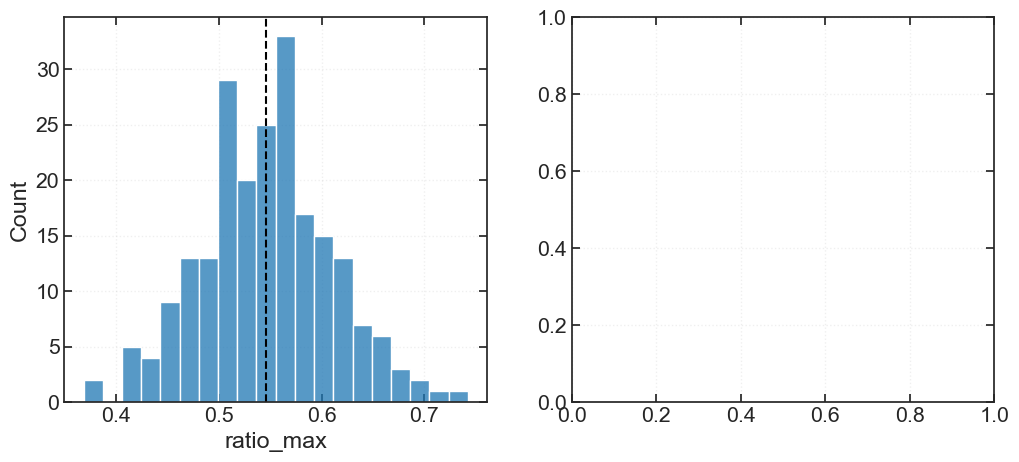

In [201]:
df_plot = df_total[df_total["ratio_mean"] <= 1]

f, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot for ratio_max
sns.histplot(df_plot["ratio_max"], bins=20, ax=ax[0])
median_max = np.median(df_plot["ratio_max"])
ax[0].axvline(median_max, linestyle="--", color="black", label=f"Median: {median_max:.3f}")

# Add std text
ax[0].text(0.95, 0.95, f"Std: {std_max:.3f}",
            transform=ax[0].transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

ax[0].legend()

# Move legend to top-left
ax[0].legend(loc="upper left")


# Plot for ratio_mean
sns.histplot(df_plot["ratio_mean"], bins=20, ax=ax[1])
median_mean = np.median(df_plot["ratio_mean"])
ax[1].axvline(median_mean, linestyle="--", color="black", label=f"Median: {median_mean:.3f}")

# Add std text
ax[1].text(0.95, 0.95, f"Std: {std_mean:.3f}",
            transform=ax[1].transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

ax[1].legend()

# Move legend to top-left
ax[1].legend(loc="upper left")

# save before showing
plt.savefig("{}/03_plots/{}_ratio_distribution_bandpass.png".format(path_out, img_i.info["name"]))
plt.show()

print(f"Median max: {median_max:.3f}")

print(f"Median mean: {median_mean:.3f}")


In [ ]:
df_plot[df_plot["ratio_mean"] >= 1]